# Train the updated emulator model from Nov 2, 2024, in which there is a scale cut at 8 arcmin. 

In [1]:
#Here are the fastnc configs

#[fastnc]
#file = ${COSMOSIS_3PCF_INTEGRATOR}/python/fastnc_interface.py
#Lmax = 50
#Mmax = 100
#nfft = 150
#projection=cent
#dlnt = 0.253758
#use-pixwin = T
#nside = 1024
#mu = 0 1 2 3
#n-phi-bin = 60
#phi-min = 0.01570796
#phi-max = 3.12588469
#n-theta-bin = 9
#theta-min = 8.15147113
#theta-max = 62.0703205
#use_cache = T
#NLA = T

In [2]:
import numpy as np
import random 
import multiprocessing
import tensorflow as tf
import matplotlib.pyplot as plt
import sys
import copy

from cosmopower import cosmopower_NN
from scipy import interpolate
from scipy import signal

In [3]:
# checking that we are using a GPU
device = 'gpu:0' if tf.test.is_gpu_available() else 'cpu' 
print('using', device, 'device \n')

# setting the seed for reproducibility
np.random.seed(0)
tf.random.set_seed(0)

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
using cpu device 



In [8]:
path_to_train = '../../'
training_info_1 = np.loadtxt(path_to_train + "output/emulator-train-cross-allparams-Nov02-list1.txt")
training_info_2 = np.loadtxt(path_to_train + "output/emulator-train-cross-allparams-Nov02-list2.txt")

In [15]:
training_info_1and2 = np.concatenate((training_info_1, training_info_2), axis=0)

print(training_info_1and2[0])

[ 3.10000000e-01  7.30000000e-01  5.00000000e-02  9.70000000e-01
 -1.00000000e+00  7.75000000e-01  7.73000000e-02  3.00000000e+00
  3.04600000e+00  0.00000000e+00  6.97186000e-02  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  6.20000000e-01
  4.90000000e-01  0.00000000e+00  0.00000000e+00  0.00000000e+00
  1.00000000e+00 -2.30026863e+08 -1.36713108e+08 -6.03661882e+07
 -3.16266629e+06 -3.45198699e+09 -2.04697082e+09 -9.02575087e+08
 -5.13874832e+07 -4.35784391e+10 -2.48727864e+10 -1.08122147e+10
 -6.86049383e+08 -1.69591106e+11 -9.26729833e+10 -3.97863524e+10
 -2.67103248e+09 -4.14708096e+11 -2.17644372e+11 -9.25535307e+10
 -6.42681192e+09 -7.93525724e+11 -4.01824896e+11 -1.69813812e+11
 -1.20881133e+10 -1.94562195e+12 -9.26682224e+11 -3.88897602e+11
 -2.85792464e+10 -4.47604754e+12 -1.98377009e+12 -8.33449042e+11
 -6.31045858e+10 -9.80644396e+12 -3.97746137e+12 -1.71591249e+12
 -1.34024957e+11 -1.52764

In [16]:
param_indices = [0,5,1,2,3]
training_info = np.ndarray(shape=(len(training_info_1and2),149))
training_info[:,:5] = training_info_1and2[:,param_indices]
training_info[:,5::4] = -1*training_info_1and2[:,25:169:4]
training_info[:,6::4] = -1*training_info_1and2[:,26:169:4]
training_info[:,7::4] = -1*training_info_1and2[:,27:169:4]
training_info[:,8::4] = -1*training_info_1and2[:,28:169:4]

In [17]:
print(np.shape(training_info))
lx = []
for i in range(len(training_info)):
    ss = 0
    for j in range(len(training_info[0])):
        if (np.isnan(training_info[i][j]) or training_info[i][j]<0) and ss == 0:
            print(i)
            ss = 1
    if ss == 0:
        lx.append(i)

lx = np.array(lx)
#print(len(lx))
training_info = training_info[lx,:]
print(np.shape(training_info))

(1500, 149)
46
47
62
63
94
127
142
143
158
190
206
223
254
287
318
382
383
398
414
447
479
494
495
510
543
558
559
574
575
606
638
639
654
670
671
702
710
735
750
751
766
767
782
799
830
831
846
895
910
926
959
990
991
1007
1022
1023
1038
1086
1119
1150
1151
1183
1199
1214
1215
1246
1263
1278
1279
1310
1343
1391
1422
1439
1470
1471
1487
(1423, 149)


In [18]:
print(np.shape(training_info))

training_params = training_info[:,:5]
training_data = training_info[:,5:]

print(np.shape(training_params))
print(np.shape(training_data))

#np.save('test_params_map3_b', training_params[400:])
#np.save('test_true_vals_map3_b', training_data[400:])

(1423, 149)
(1423, 5)
(1423, 144)


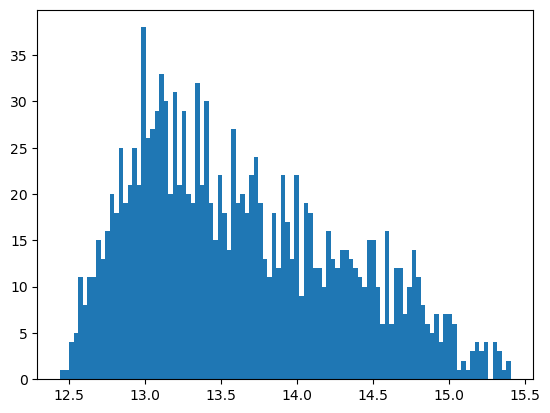

In [19]:
plt.hist(np.log10(training_data[:,100]), bins=100)
plt.show()

In [20]:
#initial try for pre-processing
#histogram of logs is less skewed than values
#try taking log10 and doing min-max after that

def log_and_norm(array):
    
    out_array = np.zeros_like(array)
    samples = len(array)
    minv_arr = np.zeros(len(array[0]))
    maxv_arr = np.zeros(len(array[0]))
    
    for i in range(len(array[0])):
        tmp = np.log10(array[:,i])
        minv = np.min(tmp)
        maxv = np.max(tmp)
        out_array[:,i] = (tmp-minv*np.ones(samples))/(maxv-minv)
        minv_arr[i] = minv
        maxv_arr[i] = maxv
        
    return(out_array, minv_arr, maxv_arr) 

In [21]:
def log_and_norm_test_set(array, minn, maxx):
    
    out_array = np.zeros_like(array)
    samples = len(array)
    minv_arr = np.zeros(len(array[0]))
    maxv_arr = np.zeros(len(array[0]))
    
    for i in range(len(array[0])):
        tmp = np.log10(array[:,i])
        minni = minn[i]
        maxxi = maxx[i]
        out_array[:,i] = (tmp-minni*np.ones(len(tmp)))/(maxxi-minni)
        
    return(out_array)

In [22]:
def post_process(array, minv_arr, maxv_arr):
    
    out_array = np.zeros_like(array)
    samples = len(array)
    
    for i in range(len(array[0])):
        tmp = array[:,i]*(maxv[i]-minv[i])+minv[i]
        out_array[:,i] = 10**(tmp)
    
    return(out_array)

In [23]:
processed_data, minv, maxv = log_and_norm(training_data[:1300])
#plt.hist(processed_data[:,0], bins=100)
#plt.show()

In [25]:
print(training_params[1410])

[0.15098633 0.86569824 0.72736328 0.05001953 0.91384766]


In [26]:
import random

Omega_m = training_params[:1300,0]
s8 = training_params[:1300,1]
h0 = training_params[:1300,2]
Omega_b = training_params[:1300,3]
n_s = training_params[:1300,4]

smallest_om = np.min(Omega_m)
biggest_om = np.max(Omega_m)
Omega_m = (Omega_m - smallest_om)/(biggest_om - smallest_om)

smallest_s8 = np.min(s8)
biggest_s8 = np.max(s8)
s8 = (s8 - smallest_s8)/(biggest_s8 - smallest_s8)

smallest_h0 = np.min(h0)
biggest_h0 = np.max(h0)
h0 = (h0 - smallest_h0)/(biggest_h0 - smallest_h0)

smallest_ob = np.min(Omega_b)
biggest_ob = np.max(Omega_b)
Omega_b = (Omega_b - smallest_ob)/(biggest_ob - smallest_ob)

smallest_ns = np.min(n_s)
biggest_ns = np.max(n_s)
n_s = (n_s - smallest_ns)/(biggest_ns - smallest_ns)

In [27]:
import pickle

omega_m_keys = {'small': smallest_om, 'large': biggest_om}
s8_keys = {'small': smallest_s8, 'large': biggest_s8}
h0_keys = {'small': smallest_h0, 'large': biggest_h0}
omega_b_keys = {'small': smallest_ob, 'large': biggest_ob}
ns_keys = {'small': smallest_ns, 'large': biggest_ns}
params_rescale = {'Omega_m': omega_m_keys, 's8': s8_keys, 'h0': h0_keys, 'Omega_b': omega_b_keys, 'ns':ns_keys}
feature_rescale = {'small': minv, 'large': maxv}
dict_rescale_full = {'params': params_rescale, 'features': feature_rescale}
file_path = 'rescaling_for_map3_network_02Nov24.pkl'
with open(file_path, 'wb') as file:
    pickle.dump(dict_rescale_full, file)

### Load training parameters and spectra

In [28]:
modes = np.arange(144)

In [29]:
train_params = {'Omega_m': Omega_m,
          's8': s8,'h0': h0, 'Omega_b': Omega_b, 'ns': n_s,
           }

In [30]:
target_data = {'features': processed_data,
               'minimum': minv,
               'maximum': maxv
}

### Training

In [31]:
# instantiate NN class
cp_nn = cosmopower_NN(parameters=['Omega_m', 's8', 'h0', 'Omega_b', 'ns'], 
                      modes=modes, 
                      n_hidden = [64, 256, 1024, 1024, 384, 192],
                      verbose=True,
                     )


Initialized cosmopower_NN model, 
mapping 5 input parameters to 144 output modes, 
using 6 hidden layers, 
with [64, 256, 1024, 1024, 384, 192] nodes, respectively. 



In [21]:
#cp_nn.restore("map3_model_02Nov24-0")

In [1]:
#noisy_input_data = np.zeros(shape=(900,80))
#for i in range(80):
#    noisy_input_data[:,i] = processed_data[:900, i] + np.random.normal(scale=0.05, size = 900)

In [32]:
with tf.device(device):
    # train
    cp_nn.train(training_parameters=train_params,
                training_features=processed_data,
                #training_features=noisy_input_data,
                filename_saved_model='map3_model_02Nov24-0',
                # cooling schedule
                validation_split=0.25,
                learning_rates=[0.01, 0.001, 0.0001, 0.00001, 0.000001],
                #learning_rates=[0.01, 0.01, 0.01, 0.01],
                batch_sizes=[60, 30, 20, 10, 5],
                gradient_accumulation_steps = [1, 1, 1, 1, 1],
                # early stopping set up
                patience_values = [200,200,150,100, 100],
                max_epochs = [2000, 2000, 2000, 2000, 2000],
                )

Starting cosmopower_NN training, 
using 25 per cent of training samples for validation. 
Performing 5 learning steps, with 
[0.01, 0.001, 0.0001, 1e-05, 1e-06] learning rates 
[60, 30, 20, 10, 5] batch sizes 
[1, 1, 1, 1, 1] gradient accumulation steps 
[200, 200, 150, 100, 100] patience values 
[2000, 2000, 2000, 2000, 2000] max epochs 

learning rate = 0.01, batch size = 60


 63%|███████████████▋         | 1255/2000 [10:03<05:58,  2.08it/s, loss=0.00302]


Validation loss = 0.002446111
Model saved.
Reached max number of epochs. Validation loss = 0.002446111
Model saved.
learning rate = 0.001, batch size = 30


 21%|█████▋                     | 421/2000 [06:00<22:31,  1.17it/s, loss=0.0012]


Validation loss = 0.0009926679
Model saved.
Reached max number of epochs. Validation loss = 0.0009926679
Model saved.
learning rate = 0.0001, batch size = 20


...

Validation loss = 0.0004936507
Model saved.
Reached max number of epochs. Validation loss = 0.0004936507
Model saved.
learning rate = 1e-05, batch size = 10


 61%|██████████████▌         | 1216/2000 [50:47<32:44,  2.51s/it, loss=0.000502]


Validation loss = 0.00048459563
Model saved.
Reached max number of epochs. Validation loss = 0.00048459563
Model saved.
learning rate = 1e-06, batch size = 5


  5%|█▏                      | 100/2000 [07:50<2:28:53,  4.70s/it, loss=9.12e-5]

Validation loss = 8.76151e-05
Model saved.
Reached max number of epochs. Validation loss = 8.76151e-05
Model saved.


In [33]:
Omega_m_test = (training_params[1300:,0]-smallest_om)/(biggest_om-smallest_om)
s8_test = (training_params[1300:,1]-smallest_s8)/(biggest_s8-smallest_s8)
h0_test = (training_params[1300:,2]-smallest_h0)/(biggest_h0-smallest_h0)
Omega_b_test = (training_params[1300:,3]-smallest_ob)/(biggest_ob-smallest_ob)
ns_test = (training_params[1300:,4]-smallest_ns)/(biggest_ns-smallest_ns)

print(len(training_params[:,0]))
print(len(Omega_m_test))
the_test_dict = {'Omega_m': Omega_m_test,
          's8': s8_test,
                 'h0': h0_test,
                 'Omega_b': Omega_b_test,
                 'ns': ns_test,
           }
    
predictions = cp_nn.predictions_np(the_test_dict)

1423
123


In [34]:
test_set_new_scale = log_and_norm_test_set(training_data[1300:], minv, maxv)

In [35]:
predictions_rescaled = post_process(predictions, minv, maxv)

In [93]:
print(np.shape(predictions))

(123, 144)


In [36]:
print(predictions_rescaled[:,0]-training_data[1300:,0])

[ 3.86108827e+04 -4.34432499e+05  4.88257020e+04  5.51474409e+05
  1.64924601e+05 -8.39155450e+04 -2.63715750e+03 -3.40793776e+05
  1.50571398e+03 -2.23657503e+05 -6.99769551e+04  1.59761334e+05
 -1.07464223e+05  1.47561363e+05 -2.68107364e+04 -1.94362286e+04
  7.09439380e+04  6.40104061e+04  3.39678034e+04  1.51451740e+06
  1.52707729e+05 -4.84447140e+03  1.85951373e+05 -2.78715748e+04
  1.09823719e+05 -4.22126417e+04  1.53000573e+05 -5.06533993e+04
 -1.55714648e+05 -2.38232324e+04  8.65320953e+04  4.24351623e+05
  2.48832656e+04 -4.71601662e+04  2.26991245e+06 -9.80440829e+05
 -1.89428194e+04 -1.69575939e+03 -9.52596325e+05  4.56783644e+04
 -1.90925189e+03 -2.45535076e+04  9.21858512e+05  4.10793400e+05
  6.25979442e+04  3.22089847e+04 -2.85220447e+05 -9.87390524e+04
  2.23835134e+06 -9.69584582e+03  9.55520563e+04  1.61413241e+05
 -4.73366148e+04 -1.26355491e+05  2.19997442e+04 -8.54064427e+04
  3.59507358e+04  3.23482214e+05  7.39975441e+04  5.50699329e+04
 -1.79770177e+03 -9.67790

In [38]:
mse = np.mean((predictions[:,0]-test_set_new_scale[:,0])**2)

In [39]:
print(mse)

1.6253862625531637e-07


In [40]:
print(predictions_rescaled[:,0])
print(training_data[1300:])

[7.49197145e+07 4.61202559e+08 2.80024146e+08 2.21349311e+08
 1.14546724e+08 2.14143665e+08 8.93183669e+07 8.74916644e+08
 1.06104325e+08 7.13626695e+08 1.42843372e+08 2.71082365e+08
 3.46301188e+08 5.12830142e+08 4.50415746e+07 2.08168402e+08
 1.40404971e+08 2.01296671e+08 1.59406014e+08 1.92817129e+08
 3.29382160e+08 4.12592470e+07 2.41483907e+08 1.15434564e+08
 2.59929766e+08 1.12310952e+08 4.07458769e+08 4.80619805e+07
 2.35239348e+08 2.05964261e+08 2.75453871e+08 5.01061046e+08
 2.84675518e+08 1.09297110e+08 2.26769729e+08 1.39528994e+08
 3.57044996e+08 8.36915657e+07 2.93929550e+08 1.41110591e+08
 2.08821143e+08 1.67270691e+08 1.72233184e+08 1.77265104e+08
 1.86247337e+08 6.37232259e+07 9.29639051e+08 1.58402406e+08
 1.40733119e+09 1.18260949e+08 1.09307551e+08 6.03437115e+08
 2.13546355e+08 2.20750849e+08 2.37317563e+08 1.43664679e+08
 4.49443895e+07 3.61237892e+08 1.67189117e+08 5.69484147e+08
 6.08918867e+07 4.40986426e+08 5.82995738e+07 1.20084973e+08
 1.38316163e+08 3.294208

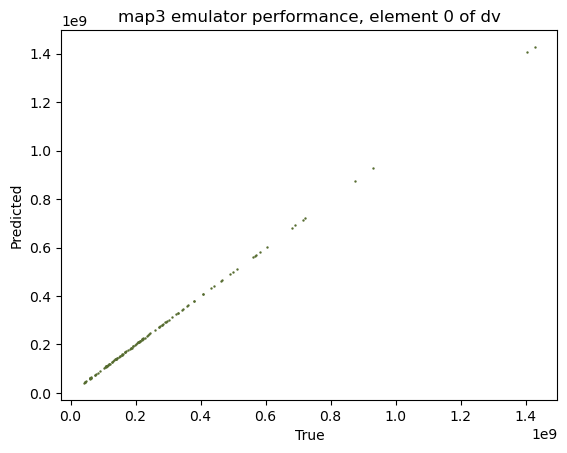

In [41]:
plt.title("map3 emulator performance, element 0 of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(training_data[1300:,0],predictions_rescaled[:,0], s=0.5, color='darkolivegreen')
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

In [42]:
test_data_all = training_data[1300:].flatten()
pred_rescaled_all = predictions_rescaled.flatten()

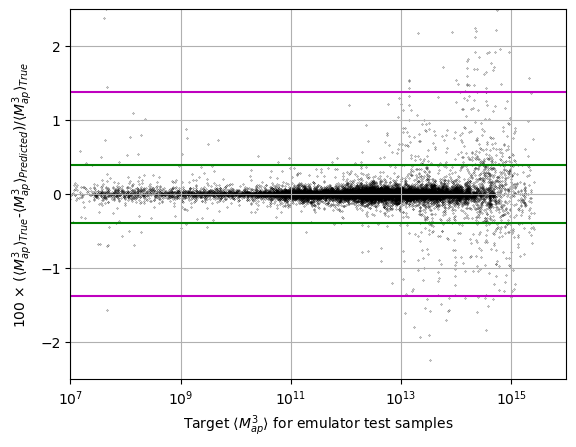

In [86]:
#plt.title("Performance of Map3 emulator")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(test_data_all,100*(pred_rescaled_all-test_data_all)/test_data_all, s=0.05, color='k')
plt.ylim(-2.5,2.5)
plt.hlines(1.38, xmin=10**(7),xmax=10**(16), color='m')
plt.hlines(-1.38, xmin=10**(7),xmax=10**(16), color='m')
plt.hlines(0.39, xmin=10**(7),xmax=10**(16), color='g')
plt.hlines(-0.39, xmin=10**(7),xmax=10**(16), color='g')
plt.xlim(10**7, 10**16)
plt.ylabel(r"100 $\times$ ($\langle M_{ap}^3 \rangle_{True}$-$\langle M_{ap}^3 \rangle_{Predicted}$)/$\langle M_{ap}^3 \rangle_{True}$")
plt.xscale('log')
plt.xlabel(r"Target $\langle M_{ap}^3 \rangle$ for emulator test samples")
plt.grid()
#plt.show()
plt.savefig('Percentual_difference_02Nov24.png', dpi=500)

In [81]:
count1 = 0
count2 = 0
for i in range(len(test_data_all)):
    x = 100*(pred_rescaled_all[i]-test_data_all[i])/test_data_all[i]
    if np.abs(x) < 0.39:
        count1+=1
    if np.abs(x) < 50:
        count2+=1
print(count1/len(test_data_all))
print(count2/len(test_data_all))

0.9705284552845529
0.9999435411020777


In [95]:
#compare performance of integrated results (at cosmoDESY3)
from astropy.io import fits
fastnc = fits.open("../../data/dv/sim_map3_emu-NLA-cosmoDESY3-02Nov24-8arcmincut-emuconfigs-no-emu.fits")
emu = fits.open("../../data/dv/sim_map3_emu-NLA-cosmoDESY3-02Nov24-8arcmincut-emulator.fits")

target = np.zeros(80)
pred = np.zeros(80)
for i in range(80):
    target[i] = fastnc[1].data[i][6]
    pred[i] = emu[1].data[i][6]
    
percent_diff = 100*(target-pred)/target
print(percent_diff)

[0.01233632 0.00505908 0.00825576 0.01211192 0.01191831 0.0049964
 0.00778772 0.0132591  0.01175193 0.00497741 0.00768996 0.01356114
 0.01171045 0.00497773 0.00766341 0.01363479 0.01093629 0.00506676
 0.00753044 0.01499252 0.0105978  0.00510008 0.00748506 0.0154203
 0.01051835 0.00510637 0.00746604 0.01551604 0.01022876 0.00513814
 0.0074205  0.01586352 0.01014591 0.00515616 0.007417   0.01599127
 0.01008825 0.00523304 0.00747826 0.0161188  0.00830254 0.00512924
 0.00693007 0.01610677 0.00701309 0.00461395 0.00597197 0.01504564
 0.00673276 0.00448845 0.0057473  0.01479201 0.00509478 0.00348415
 0.00418094 0.01260352 0.00468705 0.00323492 0.0037994  0.01206905
 0.0042693  0.00298478 0.00341627 0.01147932 0.00218253 0.001466
 0.00134882 0.00810516 0.00156838 0.00109214 0.00082912 0.00719521
 0.00092042 0.00076292 0.00037306 0.00628488 0.00037571 0.00068824
 0.0002451  0.00553197]


In [ ]:
plt.title("map3 emulator performance, element 0 of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(test_set_new_scale[:,0], predictions[:,0], s=2)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

In [ ]:
all_true = test_set_new_scale.flatten()
all_pred = predictions.flatten()

In [ ]:
plt.title("map3 emulator performance, all elements of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(all_true, all_pred, s=0.5)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

In [ ]:
plt.title("emulator performance before los integration, all cosmo params")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(all_true, all_pred-all_true, s=0.05, color='darkolivegreen')
plt.xlabel("True")
plt.ylabel("Predicted-True")
#plt.show()
plt.savefig('all_cosmo_params_emulator_performance.png')

In [ ]:
plt.title("map3 emulator performance, element 0 of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(test_set_new_scale[:,42], predictions[:,42]-test_set_new_scale[:,42], s=2)
plt.xlabel("True")
plt.ylabel("Predicted-True")
plt.show()

In [ ]:
plt.title("map3 emulator performance, element 0 of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(np.log10(training_data[1300:,35]), np.log10(predictions_rescaled[:,35]), s=2)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

In [ ]:
plt.title("map3 emulator performance, element 0 of dv")
plt.scatter(training_data[900:,1],-training_data[900:,1]+predictions_rescaled[:,1], s=2)
#plt.scatter(training_data[900:,0], predictions_rescaled[:,0], s=2)
plt.xlabel("True")
plt.ylabel("Predicted-True")
plt.show()
#plt.savefig("Map3_emulator_scatter_diff.png")

In [86]:
#test with single param. COSMO1 = n200. COSMO 2 = [0.46270508 0.75046387 0.69642578 0.03283203 0.98416016] (n1440)
Omega_m_sp = (training_params[1440:1441,0]-smallest_om)/(biggest_om-smallest_om)
s8_sp = (training_params[1440:1441,1]-smallest_s8)/(biggest_s8-smallest_s8)
h0_sp = (training_params[1440:1441,2]-smallest_h0)/(biggest_h0-smallest_h0)
Omega_b_sp = (training_params[1440:1441,3]-smallest_ob)/(biggest_ob-smallest_ob)
ns_sp = (training_params[1440:1441,4]-smallest_ns)/(biggest_ns-smallest_ns)

#print(len(training_params[:,0]))
#print(len(Omega_m_test))
the_test_dict_sp = {'Omega_m': Omega_m_sp,
          's8': s8_sp,
                 'h0': h0_sp,
                 'Omega_b': Omega_b_sp,
                 'ns': ns_sp,
           }
    
predictions_sp = cp_nn.predictions_np(the_test_dict_sp)

In [87]:
predictions_rescaled_sp = post_process(predictions_sp, minv, maxv)

In [88]:
print(np.shape(training_data[1440]))

(144,)


In [91]:
save_true = np.zeros(shape=(1,144))
save_pred = np.zeros(shape=(1,144))
save_true[0] = training_data[1440]
save_pred[0] = predictions_rescaled_sp
#print((training_data[1440]-predictions_rescaled_sp)/training_data[1440])
np.save("true_value_cosmo2", save_true)
np.save("pred_value_cosmo2", save_pred)

In [41]:
print(np.shape(predictions_rescaled_sp))

(1, 144)


In [37]:
print(np.shape(predictions_rescaled_sp[0,0::4]))

(36,)


In [92]:
filter_1_info = training_data[1440][0::4]
filter_2_info = training_data[1440][1::4]
filter_3_info = training_data[1440][2::4]
filter_4_info = training_data[1440][3::4]
zarray1 = np.array([0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07])
zarray2 = np.linspace(0.1, 1.5, num = 29)
zarray = np.concatenate((zarray1, zarray2))

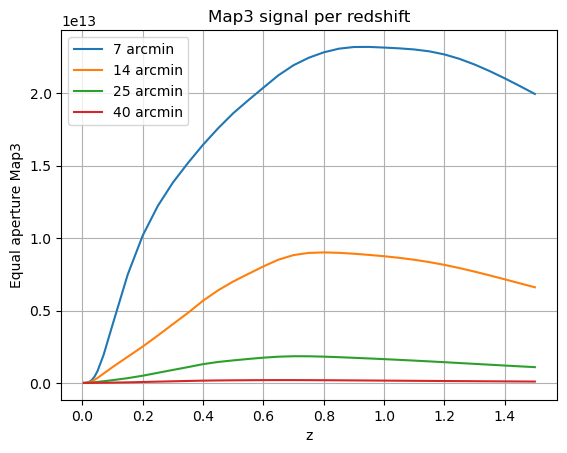

In [93]:
import matplotlib.pyplot as plt

plt.title("Map3 signal per redshift")
plt.xlabel("z")
plt.ylabel("Equal aperture Map3")
plt.plot(zarray, filter_1_info, label='7 arcmin')
plt.plot(zarray, filter_2_info, label='14 arcmin')
plt.plot(zarray, filter_3_info, label='25 arcmin')
plt.plot(zarray, filter_4_info, label='40 arcmin')
plt.grid()
plt.legend()
plt.show()

In [60]:
test_data_lowz_7arcmin = training_data[1300:][0:32:4].flatten()
pred_rescaled_lowz_7arcmin = predictions_rescaled[0:32:4].flatten()

In [61]:
test_data_lowz_14arcmin = training_data[1300:][1:32:4].flatten()
pred_rescaled_lowz_14arcmin = predictions_rescaled[1:32:4].flatten()

In [64]:
test_data_lowz_25arcmin = training_data[1300:][2:32:4].flatten()
pred_rescaled_lowz_25arcmin = predictions_rescaled[2:32:4].flatten()

In [65]:
test_data_lowz_40arcmin = training_data[1300:][3:32:4].flatten()
pred_rescaled_lowz_40arcmin = predictions_rescaled[3:32:4].flatten()

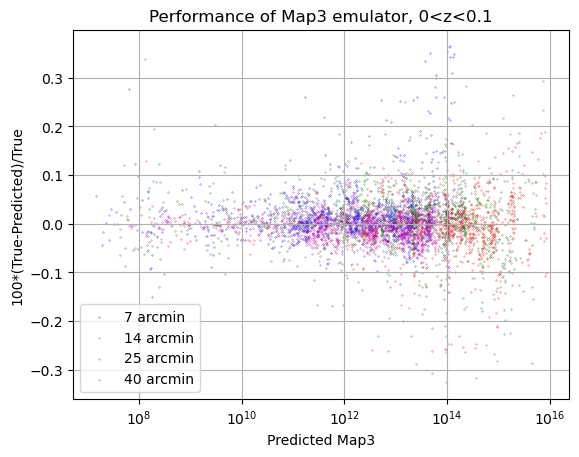

In [77]:
plt.title("Performance of Map3 emulator, 0<z<0.1")
plt.scatter(test_data_lowz_7arcmin,100*(pred_rescaled_lowz_7arcmin-test_data_lowz_7arcmin)/test_data_lowz_7arcmin, s=0.05, color='b', label='7 arcmin')
plt.scatter(test_data_lowz_14arcmin,100*(pred_rescaled_lowz_14arcmin-test_data_lowz_14arcmin)/test_data_lowz_14arcmin, s=0.05, color='r', label='14 arcmin')
plt.scatter(test_data_lowz_25arcmin,100*(pred_rescaled_lowz_25arcmin-test_data_lowz_25arcmin)/test_data_lowz_25arcmin, s=0.05, color='g', label='25 arcmin')
plt.scatter(test_data_lowz_40arcmin,100*(pred_rescaled_lowz_40arcmin-test_data_lowz_40arcmin)/test_data_lowz_40arcmin, s=0.05, color='m', label='40 arcmin')
#plt.ylim(-0.5,0.5)
plt.ylabel("100*(True-Predicted)/True")
plt.xscale('log')
plt.xlabel("Predicted Map3")
plt.legend()
plt.grid()
plt.show()

In [67]:
test_data_midz_7arcmin = training_data[1300:][32:80:4].flatten()
pred_rescaled_midz_7arcmin = predictions_rescaled[32:80:4].flatten()
test_data_midz_14arcmin = training_data[1300:][33:80:4].flatten()
pred_rescaled_midz_14arcmin = predictions_rescaled[33:80:4].flatten()
test_data_midz_25arcmin = training_data[1300:][34:80:4].flatten()
pred_rescaled_midz_25arcmin = predictions_rescaled[34:80:4].flatten()
test_data_midz_40arcmin = training_data[1300:][35:80:4].flatten()
pred_rescaled_midz_40arcmin = predictions_rescaled[35:80:4].flatten()

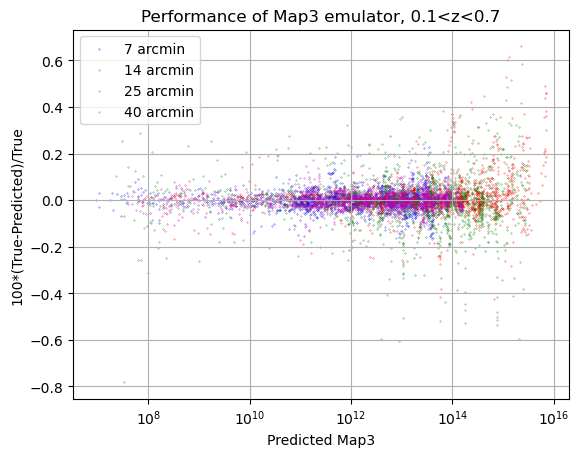

In [76]:
plt.title("Performance of Map3 emulator, 0.1<z<0.7")
plt.scatter(test_data_midz_7arcmin,100*(pred_rescaled_midz_7arcmin-test_data_midz_7arcmin)/test_data_midz_7arcmin, s=0.05, color='b', label='7 arcmin')
plt.scatter(test_data_midz_14arcmin,100*(pred_rescaled_midz_14arcmin-test_data_midz_14arcmin)/test_data_midz_14arcmin, s=0.05, color='r', label='14 arcmin')
plt.scatter(test_data_midz_25arcmin,100*(pred_rescaled_midz_25arcmin-test_data_midz_25arcmin)/test_data_midz_25arcmin, s=0.05, color='g', label='25 arcmin')
plt.scatter(test_data_midz_40arcmin,100*(pred_rescaled_midz_40arcmin-test_data_midz_40arcmin)/test_data_midz_40arcmin, s=0.05, color='m', label='40 arcmin')
#plt.ylim(-0.5,0.5)
plt.ylabel("100*(True-Predicted)/True")
plt.xscale('log')
plt.xlabel("Predicted Map3")
plt.legend()
plt.grid()
plt.show()

In [99]:
path_to_train = '../../'
cosmo2_morez = np.loadtxt(path_to_train + "output/true-map3-vals-cosmo2.txt")[25:-2]
print(np.shape(cosmo2_morez))

(256,)


In [102]:
save_true_finez = np.zeros(shape=(1,256))
save_true_finez[0] = cosmo2_morez
np.save("true_value_cosmo2_fine_z", save_true_finez)